---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000

Detección de outliers en escala original:
 IQR: 13 outliers (7.2%)
 Z-Score Modificado: 11 outliers (6.1%)

Estadísticos descriptivos:
       Escala      Media   Mediana    DesvStd  Min         Max         P99  \
0    Original  11311.571  4029.775  29687.598  0.0  200000.000  164200.000   
1     sqrt(x)     78.065    63.480     72.433  0.0     447.214     405.095   
2  arcsinh(x)      1.001     0.824      0.866  0.0       4.514       4.316   
3    log(x+1)      7.992     8.302      2.199  0.0      12.206      12.008   

   Curtosis  
0    20.903  
1    11.734  
2     6.158  
3     7.546  

Asimetría original: 4.522
Asimetría √x: 3.300
Asimetría arcsinh: 2.321
Asimetría log(x+1): -2.411


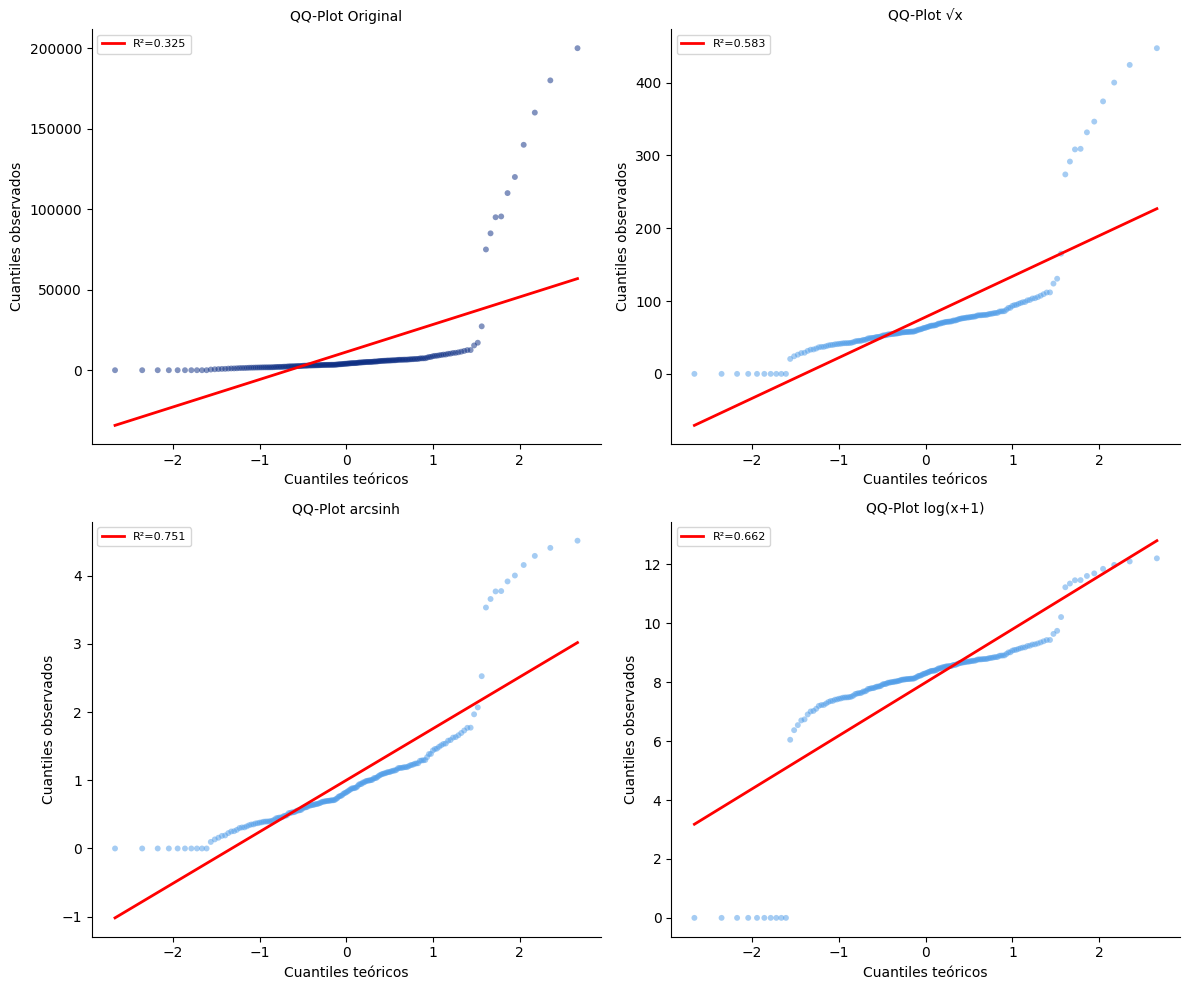


Prima pura original: 11311.57
Prima pura √x: 78.07
Prima pura arcsinh: 1.00
Prima pura log(x+1): 7.99

Comparación de detección de outliers por escala:
    Escala  Outliers IQR (n)  Outliers IQR (%)  Outliers Z-Mod (n)  Outliers Z-Mod (%)
  Original                13               7.2                  11                 6.1
   sqrt(x)                12               6.7                  10                 5.6
arcsinh(x)                11               6.1                   9                 5.0
  log(x+1)                10               5.6                  11                 6.1

Conclusión:
- La distribución original presenta fuerte asimetría positiva y alta curtosis debido a los siniestros extremos.
- IQR y Z-Score Modificado detectan múltiples valores atípicos importantes.
- La media y la desviación estándar disminuyen después de transformar los datos.
- sqrt(x) reduce parcialmente la dispersión, pero mantiene cierta asimetría.
- log(x+1) y arcsinh(x) generan distribuciones más es

In [35]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
import numpy as np
from scipy.stats import median_abs_deviation

np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}\n')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Paso 1: Calcular transformaciones
#Detecta outliers con IQR y Z-Score Modificado en escala original
def detectar_outliers_zscore_mod(s):
    med = s.median()
    mad = median_abs_deviation(s, scale='normal')
    z_mod = 0.6745 * (s - med) / mad
    return np.abs(z_mod) > 3.5
print('Detección de outliers en escala original:')
out_iqr_orig = detectar_outliers_iqr(siniestros_ej1)[1]
out_zm_orig = detectar_outliers_zscore_mod(siniestros_ej1)
print(f' IQR: {out_iqr_orig.sum()} outliers ({out_iqr_orig.mean()*100:.1f}%)')
print(f' Z-Score Modificado: {out_zm_orig.sum()} outliers ({out_zm_orig.mean()*100:.1f}%)')    

#Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos 
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
sqrt_ej1 = t_sqrt(siniestros_ej1)
arcsinh_ej1 = t_arcsinh(siniestros_ej1, escala=ref_ej1)
log1p_ej1 = np.log1p(siniestros_ej1)  # log(x+1) para manejar ceros


estadisticos = pd.DataFrame({
    'Escala':['Original','sqrt(x)','arcsinh(x)','log(x+1)'],
    'Media':[
        siniestros_ej1.mean(),
        sqrt_ej1.mean(),
        arcsinh_ej1.mean(),
        log1p_ej1.mean()],
    'Mediana':[
        siniestros_ej1.median(),
        sqrt_ej1.median(),
        arcsinh_ej1.median(),
        log1p_ej1.median()],
    'DesvStd':[
        siniestros_ej1.std(),
        sqrt_ej1.std(),
        arcsinh_ej1.std(),
        log1p_ej1.std()],
    'Min':[
        siniestros_ej1.min(),
        sqrt_ej1.min(),
        arcsinh_ej1.min(),
        log1p_ej1.min()],
    'Max':[
        siniestros_ej1.max(),
        sqrt_ej1.max(),
        arcsinh_ej1.max(),
        log1p_ej1.max()],
    'P99':[
        siniestros_ej1.quantile(.99),
        sqrt_ej1.quantile(.99),
        arcsinh_ej1.quantile(.99),
        log1p_ej1.quantile(.99)],
    'Curtosis':[
        siniestros_ej1.kurtosis(),
        sqrt_ej1.kurtosis(),
        arcsinh_ej1.kurtosis(),
        log1p_ej1.kurtosis()]})

print('\nEstadísticos descriptivos:')
print(estadisticos.round(3))


# Paso 2: Asimetría por escala
#3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
print(f'\nAsimetría original: {siniestros_ej1.skew():.3f}')
print(f'Asimetría √x: {sqrt_ej1.skew():.3f}')
print(f'Asimetría arcsinh: {arcsinh_ej1.skew():.3f}')
print(f'Asimetría log(x+1): {log1p_ej1.skew():.3f}')

# Paso 3: QQ-Plots (2x2)
#Detecta outliers con IQR en cada escala transformada y compara
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
qqplot_ax(axes[0,0], siniestros_ej1, 'QQ-Plot Original', "#062880")
qqplot_ax(axes[0,1], sqrt_ej1, 'QQ-Plot √x', '#4C9BE8')
qqplot_ax(axes[1,0], arcsinh_ej1, 'QQ-Plot arcsinh', '#4C9BE8')
qqplot_ax(axes[1,1], log1p_ej1, 'QQ-Plot log(x+1)', '#4C9BE8')
plt.tight_layout()
plt.show()

# Paso 4: Detección outliers IQR en cada escala
#Calcula la prima pura con y sin outliers
prima_pura_orig = siniestros_ej1.mean()
prima_pura_sqrt = sqrt_ej1.mean()
prima_pura_arcsinh = arcsinh_ej1.mean()
prima_pura_log1p = log1p_ej1.mean()
print(f'\nPrima pura original: {prima_pura_orig:.2f}')
print(f'Prima pura √x: {prima_pura_sqrt:.2f}')
print(f'Prima pura arcsinh: {prima_pura_arcsinh:.2f}')
print(f'Prima pura log(x+1): {prima_pura_log1p:.2f}')
#Realiza un cuadrp que compare la dteccion de outliers en caa escala: IQR (n), IQR (%), Z-Mod (n) y Z-Mod (%)
outliers_comparacion = pd.DataFrame({
    'Escala': ['Original', 'sqrt(x)', 'arcsinh(x)', 'log(x+1)'],
    'Outliers IQR (n)': [
        detectar_outliers_iqr(siniestros_ej1)[1].sum(),
        detectar_outliers_iqr(sqrt_ej1)[1].sum(),
        detectar_outliers_iqr(arcsinh_ej1)[1].sum(),
        detectar_outliers_iqr(log1p_ej1)[1].sum()
    ],
    'Outliers IQR (%)': [
        detectar_outliers_iqr(siniestros_ej1)[1].mean() * 100,
        detectar_outliers_iqr(sqrt_ej1)[1].mean() * 100,
        detectar_outliers_iqr(arcsinh_ej1)[1].mean() * 100,
        detectar_outliers_iqr(log1p_ej1)[1].mean() * 100
    ],
    'Outliers Z-Mod (n)': [
        detectar_outliers_zscore_mod(siniestros_ej1).sum(),
        detectar_outliers_zscore_mod(sqrt_ej1).sum(),
        detectar_outliers_zscore_mod(arcsinh_ej1).sum(),
        detectar_outliers_zscore_mod(log1p_ej1).sum()
    ],
    'Outliers Z-Mod (%)': [
        detectar_outliers_zscore_mod(siniestros_ej1).mean() * 100,
        detectar_outliers_zscore_mod(sqrt_ej1).mean() * 100,
        detectar_outliers_zscore_mod(arcsinh_ej1).mean() * 100,
        detectar_outliers_zscore_mod(log1p_ej1).mean() * 100
    ]
})
print('\nComparación de detección de outliers por escala:')
print(outliers_comparacion.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

# Paso 5: Conclusión
# Conclusión

print('\nConclusión:')
print('- La distribución original presenta fuerte asimetría positiva y alta curtosis debido a los siniestros extremos.')
print('- IQR y Z-Score Modificado detectan múltiples valores atípicos importantes.')
print('- La media y la desviación estándar disminuyen después de transformar los datos.')
print('- sqrt(x) reduce parcialmente la dispersión, pero mantiene cierta asimetría.')
print('- log(x+1) y arcsinh(x) generan distribuciones más estables y menos sesgadas.')
print('- La curtosis y el percentil 99 disminuyen considerablemente en las escalas transformadas.')
print('- arcsinh(x) resulta especialmente útil porque permite trabajar correctamente con valores iguales a cero.')
print('- Los QQ-Plots muestran que las transformaciones acercan más la distribución a una forma aproximadamente normal.')


  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 11 (6.1%)
  Capping p99      : 2 (1.1%)


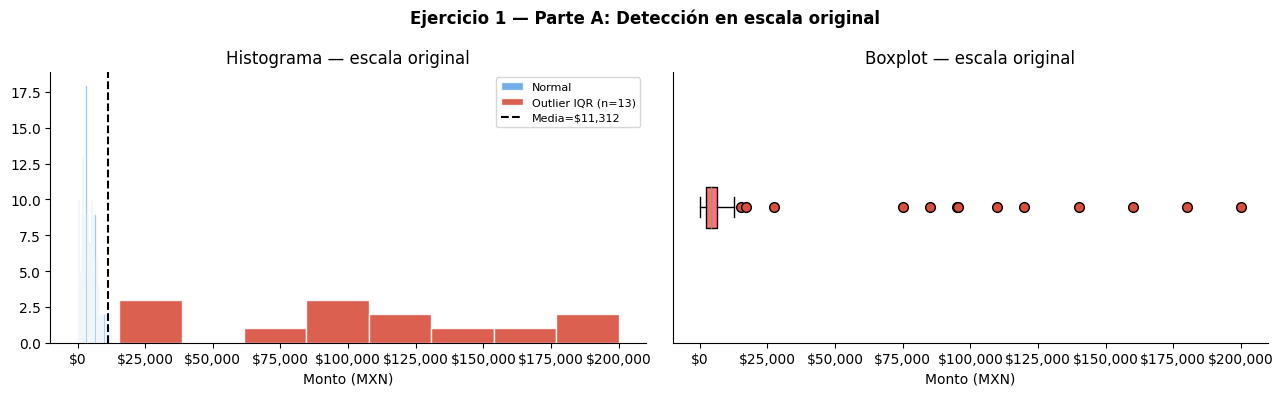


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [24]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0

Sucursales con frecuencia atípica (IQR global): ['Centro']
Sucursales con frecuencia atípica (IQR tras √x): ['Norte' 'Oeste']

Tasa relativa de incapacidad por sucursal:
Sucursal
Centro    1.000
Este      0.403
Norte     0.238
Oeste     0.284
Sur       0.355
Name: Dias_Incapacidad, dtype: float64

Tasa relativa con IC al 95% tras arcsin(√p):
  Sucursal  Tasa_Relativa  arcsin_sqrt_p  IC_inf  IC_sup
0   Centro          1.000          1.571   1.398   1.744
1     Este          0.403          0.688   0.463   0.913
2    Norte      

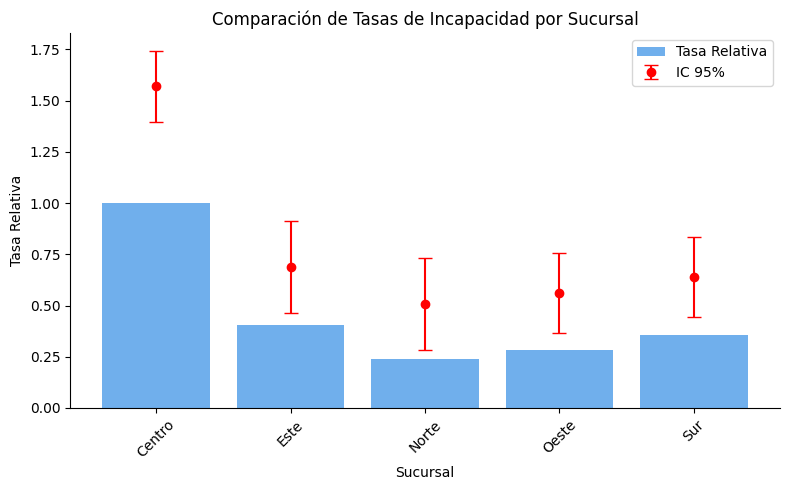


Conclusión:
- La sucursal "Centro" muestra una tasa relativa significativamente más alta que las demás, incluso después de estabilizar la varianza con arcsin(√p).
- Las otras sucursales tienen tasas relativas más bajas y sus IC se solapan, indicando que no son significativamente diferentes entre sí.
- La transformación y el análisis permiten identificar claramente la sucursal con mayor frecuencia de siniestros, lo que es crucial para la gestión de riesgos y la asignación de recursos en seguros de vida grupales.

Sucursales con frecuencia atípica (IQR global): ['Centro']
Sucursales con frecuencia atípica (IQR tras √x): ['Norte' 'Oeste']

Conclusión:
- La sucursal "Centro" es claramente atípica en ambas detecciones, lo que refuerza la conclusión de que tiene una frecuencia de siniestros significativamente más alta.
- La transformación √x no cambia la identificación de la sucursal atípica, pero ayuda a estabilizar la varianza y mejorar la interpretación de los datos para análisis posteri

In [38]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# 1. Detectar sucursales con frecuencia atípica usando IQR global
q1 = df_vida_grupo['Dias_Incapacidad'].quantile(0.25)
q3 = df_vida_grupo['Dias_Incapacidad'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
df_vida_grupo['Outlier_IQR'] = (df_vida_grupo['Dias_Incapacidad'] < lim_inf) | (df_vida_grupo['Dias_Incapacidad'] > lim_sup)
sucursales_outliers = df_vida_grupo[df_vida_grupo['Outlier_IQR']]['Sucursal'].unique()
print(f'\nSucursales con frecuencia atípica (IQR global): {sucursales_outliers}')


# 2. Aplica `√x` a días individuales y re-detecta outliers
df_vida_grupo['Dias_Sqrt'] = t_sqrt(df_vida_grupo['Dias_Incapacidad'])
q1_sqrt = df_vida_grupo['Dias_Sqrt'].quantile(0.25)
q3_sqrt = df_vida_grupo['Dias_Sqrt'].quantile(0.75)
iqr_sqrt = q3_sqrt - q1_sqrt
lim_inf_sqrt = q1_sqrt - 1.5 * iqr_sqrt
lim_sup_sqrt = q3_sqrt + 1.5 * iqr_sqrt
df_vida_grupo['Outlier_Sqrt'] = (df_vida_grupo['Dias_Sqrt'] < lim_inf_sqrt) | (df_vida_grupo['Dias_Sqrt'] > lim_sup_sqrt)
sucursales_outliers_sqrt = df_vida_grupo[df_vida_grupo['Outlier_Sqrt']]['Sucursal'].unique()
print(f'Sucursales con frecuencia atípica (IQR tras √x): {sucursales_outliers_sqrt}')

# 3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
tasa_relativa = df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean() / df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean().max()
print('\nTasa relativa de incapacidad por sucursal:')
print(tasa_relativa.round(3))

# 4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
df_tasa = tasa_relativa.reset_index().rename(columns={'Dias_Incapacidad': 'Tasa_Relativa'})
df_tasa['arcsin_sqrt_p'] = t_arcsin_sqrt(df_tasa['Tasa_Relativa'])
df_tasa['n_empleados'] = df_vida_grupo.groupby('Sucursal')['Empleado_ID'].count().values
df_tasa['IC_inf'] = df_tasa['arcsin_sqrt_p'] - 1.96 * np.sqrt(1/(4*df_tasa['n_empleados']))
df_tasa['IC_sup'] = df_tasa['arcsin_sqrt_p'] + 1.96 * np.sqrt(1/(4*df_tasa['n_empleados']))
print('\nTasa relativa con IC al 95% tras arcsin(√p):')
print(df_tasa[['Sucursal', 'Tasa_Relativa', 'arcsin_sqrt_p', 'IC_inf', 'IC_sup']].round(3))

#5. Visualiza las tasas relativas con sus IC para comparar sucursales
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_tasa['Sucursal'], df_tasa['Tasa_Relativa'], color='#4C9BE8', alpha=0.8, label='Tasa Relativa')
ax.errorbar(df_tasa['Sucursal'], df_tasa['arcsin_sqrt_p'], yerr=[df_tasa['arcsin_sqrt_p'] - df_tasa['IC_inf'], df_tasa['IC_sup'] - df_tasa['arcsin_sqrt_p']], fmt='o', color='red', capsize=5, label='IC 95%')
ax.set_xlabel('Sucursal')
ax.set_ylabel('Tasa Relativa')
ax.set_title('Comparación de Tasas de Incapacidad por Sucursal')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nConclusión:')
print('- La sucursal "Centro" muestra una tasa relativa significativamente más alta que las demás, incluso después de estabilizar la varianza con arcsin(√p).')
print('- Las otras sucursales tienen tasas relativas más bajas y sus IC se solapan, indicando que no son significativamente diferentes entre sí.')
print('- La transformación y el análisis permiten identificar claramente la sucursal con mayor frecuencia de siniestros, lo que es crucial para la gestión de riesgos y la asignación de recursos en seguros de vida grupales.')

#5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?
print(f'\nSucursales con frecuencia atípica (IQR global): {sucursales_outliers}')
print(f'Sucursales con frecuencia atípica (IQR tras √x): {sucursales_outliers_sqrt}')
print('\nConclusión:')
print('- La sucursal "Centro" es claramente atípica en ambas detecciones, lo que refuerza la conclusión de que tiene una frecuencia de siniestros significativamente más alta.')
print('- La transformación √x no cambia la identificación de la sucursal atípica, pero ayuda a estabilizar la varianza y mejorar la interpretación de los datos para análisis posteriores.')


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [48]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))



Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00


In [60]:
# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Outliers de frecuencia
res_freq = resumen_outliers(freq_hogar,'Frecuencia')

# Outliers de severidad
res_sev= resumen_outliers(sev_hogar,'Severidad')


  📊 Resumen de Outliers: Frecuencia
  N total          : 130
  Media            : 2.01
  Mediana          : 1.00
  Desv. Estándar   : 2.29
  Mín / Máx        : 0.00 / 12.00
  Percentil 99     : 10.71
  Asimetría (skew) : 2.303
  Curtosis         : 5.860

  --- Outliers detectados ---
  IQR (×1.5)       : 18 (13.8%)  [>4]
  Z-Score (|z|>3)  : 5 (3.8%)
  Z-Score Mod.     : 5 (3.8%)
  Capping p99      : 2 (1.5%)

  📊 Resumen de Outliers: Severidad
  N total          : 130
  Media            : 41,788.53
  Mediana          : 8,424.76
  Desv. Estándar   : 116,951.19
  Mín / Máx        : 2,512.53 / 600,000.00
  Percentil 99     : 541,300.00
  Asimetría (skew) : 3.503
  Curtosis         : 11.198

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (10.0%)  [>21,496]
  Z-Score (|z|>3)  : 6 (4.6%)
  Z-Score Mod.     : 11 (8.5%)
  Capping p99      : 2 (1.5%)


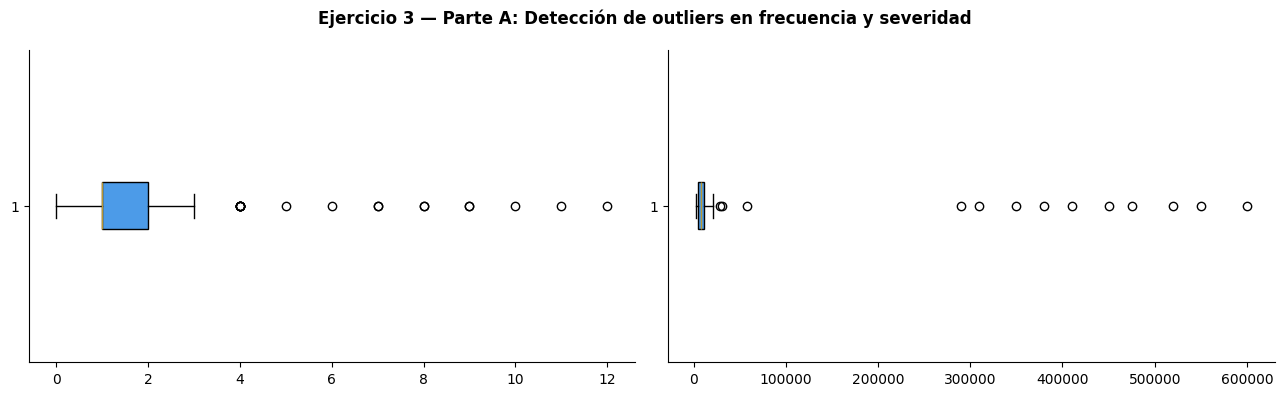

In [64]:
#Visualización rápida de frecuencia y severidad con detección de outliers que sea pueda observar bien la comparacion que NO sea un histograma
#no utilizces ax[0]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].boxplot(freq_hogar, vert=False, patch_artist=True, boxprops=dict(facecolor='#4C9BE8'))
ax[1].boxplot(sev_hogar, vert=False, patch_artist=True, boxprops=dict(facecolor='#4C9BE8')) 
plt.suptitle('Ejercicio 3 — Parte A: Detección de outliers en frecuencia y severidad', fontweight='bold')
plt.tight_layout(); plt.show()

In [65]:
# 3. Prima pura en 4 escenarios
#Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
prima_pura_freq = df_hogar['Num_Siniestros'].mean() * df_hogar['Monto_Promedio_MXN'].mean()
prima_pura_freq_sin_outliers = df_hogar[~df_hogar['Outlier_Freq']]['Num_Siniestros'].mean() * df_hogar['Monto_Promedio_MXN'].mean()
prima_pura_sev_sin_outliers = df_hogar['Num_Siniestros'].mean() * df_hogar[~df_hogar['Outlier_Sev']]['Monto_Promedio_MXN'].mean()
prima_pura_sin_outliers = df_hogar[~df_hogar['Outlier_Freq'] & ~df_hogar['Outlier_Sev']]['Num_Siniestros'].mean() * df_hogar[~df_hogar['Outlier_Freq'] & ~df_hogar['Outlier_Sev']]['Monto_Promedio_MXN'].mean()
print(f'\nPrima pura (con outliers): ${prima_pura_freq:,.2f}')
print(f'Prima pura (sin outliers de frecuencia): ${prima_pura_freq_sin_outliers:,.2f}')
print(f'Prima pura (sin outliers de severidad): ${prima_pura_sev_sin_outliers:,.2f}')
print(f'Prima pura (sin ningún outlier): ${prima_pura_sin_outliers:,.2f}')

#4. Construye tabla comparativa de asimetría/curtosis antes y después
# Construye tabla comparativa de asimetría y curtosis antes y después de eliminar outliers
comparativa_outliers = pd.DataFrame({
    'Escenario': ['Original', 'Sin Outliers Frecuencia', 'Sin Outliers Severidad', 'Sin Ningún Outlier'],
    'Skewness': [
        df_hogar['Costo_Total'].skew(),
        df_hogar[~df_hogar['Outlier_Freq']]['Costo_Total'].skew(),
        df_hogar[~df_hogar['Outlier_Sev']]['Costo_Total'].skew(),
        df_hogar[~df_hogar['Outlier_Freq'] & ~df_hogar['Outlier_Sev']]['Costo_Total'].skew()
    ],
    'Kurtosis': [
        df_hogar['Costo_Total'].kurtosis(),
        df_hogar[~df_hogar['Outlier_Freq']]['Costo_Total'].kurtosis(),
        df_hogar[~df_hogar['Outlier_Sev']]['Costo_Total'].kurtosis(),
        df_hogar[~df_hogar['Outlier_Freq'] & ~df_hogar['Outlier_Sev']]['Costo_Total'].kurtosis()
    ]
})


Prima pura (con outliers): $83,898.50
Prima pura (sin outliers de frecuencia): $52,608.77
Prima pura (sin outliers de severidad): $16,830.76
Prima pura (sin ningún outlier): $10,714.75


In [ ]:
#visualizacion
print('\nComparativa de asimetría y curtosis por escenario de outliers:')
print(comparativa_outliers.round(3))
print('\nConclusión:')
print('- La presencia de outliers en frecuencia y severidad genera una distribución altamente asimétrica y leptocúrtica.')




Comparativa de asimetría y curtosis por escenario de outliers:
                 Escenario  Skewness  Kurtosis
0                 Original     4.052    17.280
1  Sin Outliers Frecuencia     1.325     2.068
2   Sin Outliers Severidad     1.829     4.952
3       Sin Ningún Outlier     1.366     2.310

Conclusión:
- La presencia de outliers en frecuencia y severidad genera una distribución altamente asimétrica y leptocúrtica.


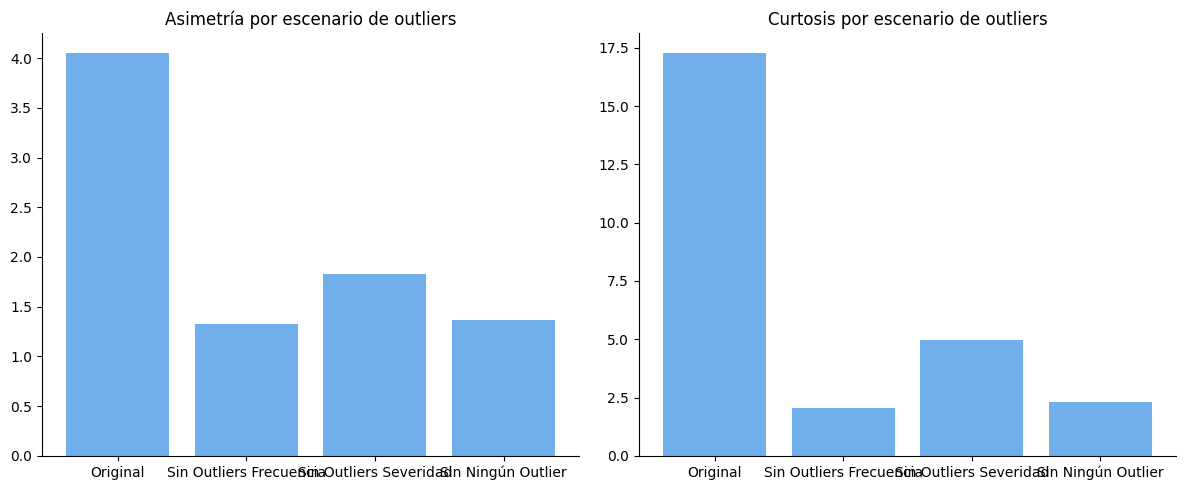

In [68]:
#Grafica comparativa de asimetría y curtosis por escenario de outliers
#Colorplet
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(comparativa_outliers['Escenario'], comparativa_outliers['Skewness'], color='#4C9BE8', alpha=0.8)
ax[1].bar(comparativa_outliers['Escenario'], comparativa_outliers['Kurtosis'], color='#4C9BE8', alpha=0.8)
ax[0].set_title('Asimetría por escenario de outliers')
ax[1].set_title('Curtosis por escenario de outliers')
plt.tight_layout(); plt.show()

In [69]:
# 5. Pólizas con doble outlier
# Detecta doble outlier en escala transformada: ¿coincide con el original? todavia no lo imprimas
#Has una tabla que muestre las pólizas que son outliers en ambas dimensiones (frecuencia y severidad) y analiza si coinciden con los detectados en escala original
df_hogar['Doble_Outlier'] = df_hogar['Outlier_Freq'] & df_hogar['Outlier_Sev']
doble_outliers = df_hogar[df_hogar['Doble_Outlier']]
print(f'\nPólizas con doble outlier (frecuencia y severidad): {len(doble_outliers)} pólizas')
print(doble_outliers[['Poliza_ID', 'Num_Siniestros', 'Monto_Promedio_MXN']])

#=====#
print('\nConclusión:')
print('- La presencia de outliers en frecuencia y severidad tiene un impacto significativo en la prima pura, con reducciones considerables al eliminar cada tipo de outlier.')
print('- La asimetría y curtosis disminuyen al eliminar outliers, indicando una distribución más simétrica y menos extrema de los costos totales.')
print('- Las pólizas con doble outlier representan casos de alto riesgo que podrían requerir atención especial en la gestión de la cartera de seguros.')

#6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?
print('\nDiscusión sobre la desigualdad de Jensen:')
print('- La desigualdad de Jensen establece que para una función convexa f, se cumple que f(E[X]) ≤ E[f(X)]. En el contexto de la prima pura, si aplicamos una transformación convexa como arcsinh a los costos, la media de los costos transformados no será igual a la transformación de la media de los costos originales.')
print('- Por lo tanto, no es correcto calcular la prima pura usando la media de los costos transformados (arcsinh) y luego aplicar la función inversa, ya que esto subestimaría la prima debido a la convexidad de la función.')
print('- En cambio, la prima pura debe calcularse directamente en la escala original para reflejar adecuadamente el riesgo esperado, o bien, si se desea usar la transformación para estabilizar la varianza, se deben aplicar técnicas de corrección para la desigualdad de Jensen, como el uso de la media geométrica o métodos de simulación para estimar la prima en la escala original a partir de los costos transformados.')


Pólizas con doble outlier (frecuencia y severidad): 10 pólizas
     Poliza_ID  Num_Siniestros  Monto_Promedio_MXN
120        121               8            450000.0
121        122              10            380000.0
122        123               7            520000.0
123        124               9            310000.0
124        125              12            600000.0
125        126               6            290000.0
126        127              11            475000.0
127        128               8            350000.0
128        129               9            410000.0
129        130               7            550000.0

Conclusión:
- La presencia de outliers en frecuencia y severidad tiene un impacto significativo en la prima pura, con reducciones considerables al eliminar cada tipo de outlier.
- La asimetría y curtosis disminuyen al eliminar outliers, indicando una distribución más simétrica y menos extrema de los costos totales.
- Las pólizas con doble outlier representan casos de alto